# Tutorial: End-to-End Closure Training with Configs, Splits, Evaluation, and Deployable Artifacts

This notebook shows a practical workflow:

1. Create a YAML experiment config
2. Build train/val/test CSV splits with `scripts/datasplit.py`
3. Train with Lightning using custom checkpointing
4. Evaluate with MSE and $R^2$ (plus extra regression diagnostics)
5. Visualize diagonal and off-diagonal channels with robust controls
6. Export deployable `.pt` artifacts with normalization + TorchScript

In [1]:
from pathlib import Path
import json
#import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import torch
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

from closure import ClosureDataModule, ClosureLitModule, MLP, load_paths
import closure.evaluation as ev
from closure.visualization import plot_pred_targets

## 1) Paths and working directories

We load `data_dir` and `work_dir` from `paths.yaml` via `load_paths()`, then derive experiment sub-directories. This keeps experiments reproducible and portable across machines.

Copy `paths.yaml.example` to `paths.yaml` in the project root and edit `work_dir` / `data_dir` for your machine. The file is git-ignored so local settings never leak into commits.

In [2]:
# Derive project root from this notebook's location (examples/)
project_root = Path('..').resolve()
paths = load_paths(str(project_root / 'paths.yaml'))

data_root = Path(paths['data_dir'])
work_dir = Path(paths['work_dir']) / 'dev' / 'dev16'
ecsim_dir = data_root / 'ecsim'

split_dir = project_root / 'splits' / 'split1'
config_dir = work_dir / 'configs'
artifact_dir = work_dir / 'artifacts'

for p in [work_dir, split_dir, config_dir, artifact_dir]:
    p.mkdir(parents=True, exist_ok=True)

print('project_root:', project_root)
print('data_root   :', data_root)
print('ecsim_dir   :', ecsim_dir)
print('work_dir    :', work_dir)
print('split_dir   :', split_dir)
print('config_dir  :', config_dir)
print('artifact_dir:', artifact_dir)

project_root: /volume1/scratch/georgem/closure
data_root   : /volume1/scratch/share_dir
ecsim_dir   : /volume1/scratch/share_dir/ecsim
work_dir    : /volume1/scratch/georgem/closure/models/dev/dev16
split_dir   : /volume1/scratch/georgem/closure/splits/split1
config_dir  : /volume1/scratch/georgem/closure/models/dev/dev16/configs
artifact_dir: /volume1/scratch/georgem/closure/models/dev/dev16/artifacts


## 2) Build a YAML experiment config

We save one config file that captures data, model, optimization, and trainer settings.

`data_folder` and `norm_folder` are stored as **relative identifiers** — `ClosureDataModule._resolve_path()` resolves them at `setup()` time against `data_dir` and `work_dir` from `paths.yaml`.

In [ ]:
import yaml

# Config stores relative identifiers; ClosureDataModule._resolve_path() will
# resolve data_folder against data_dir and norm_folder against work_dir from
# paths.yaml at setup() time.
run_config = {
    'name': 'baseline',
    'data': {
        'data_folder': 'ecsim',
        'norm_folder': 'dev/dev16',
        'flatten': True,
        'scaler_features': True,
        'scaler_targets': True,
        'prescaler_features': ['arcsinh','arcsinh','arcsinh','arcsinh','arcsinh','arcsinh',None,None,None,None],
        # Diagonal pressures are positive-like in this setup; off-diagonals are signed.
        'prescaler_targets': ['log','log','log',None,None,None],
        'read_features_targets_kwargs': {
            'fields_to_read': {
                'B': True,
                'E': True,
                'B_ext': False,
                'E_ext': False,
                'divB': False,
                'rho': True,
                'N': False,
                'Qrem': False,
                'J': True,
                'P': True,
                'PI': True,
                'divP': False,
                'Ohmres': False,
                'Heat_flux': False,
                'gyro_radius': False,
                'EF': False,
            },
            'request_features': [
                'rho_e',
                'Bx','By','Bz',
                'Jx_e','Jy_e','Jz_e',
                'Vx_e','Vy_e','Vz_e',
            ],
            'request_targets': ['Pxx_e','Pyy_e','Pzz_e','Pxy_e','Pxz_e','Pyz_e'],
            'choose_species': ['e', None],
            'choose_x': [0, 256],
            'choose_y': [0, 256],
            'verbose': False,
        },
    },
    'model': {
        'feature_dims': [10, 60, 80, 50, 40, 6],
        'activations': ['Tanh', 'Tanh', 'Tanh', 'Tanh', None],
    },
    'optimizer': {
        'criterion': 'MSELoss',
        'metrics': ['R2Score'],
        'optimizer': 'Adam',
        'lr': 5e-4,
        'weight_decay': 0.0,
        'scheduler': 'ReduceLROnPlateau',
        'scheduler_kwargs': {'mode': 'min', 'factor': 0.6, 'patience': 4, 'threshold': 1e-3},
    },
    'trainer': {
        'batch_size': 1024,
        'num_workers': 8,
        'max_epochs': 40,
        'accelerator': 'gpu',
        'devices': 1,
        'precision': '16-mixed',
        'gradient_clip_val': 1.0,
        'log_every_n_steps': 25,
    },
}

config_path = config_dir / 'model.yaml'
with open(config_path, 'w') as f:
    yaml.safe_dump(run_config, f, sort_keys=False)

print('Wrote:', config_path)

Wrote: /volume1/scratch/georgem/closure/models/dev/dev16/configs/model.yaml


Inspecting the saved YAML confirms exactly what will be run.

In [4]:
print(config_path.read_text()[:1600])

name: baseline
data:
  data_folder: /volume1/scratch/share_dir/ecsim
  norm_folder: /volume1/scratch/georgem/closure/models/dev/dev16
  flatten: true
  scaler_features: true
  scaler_targets: true
  prescaler_features:
  - arcsinh
  - arcsinh
  - arcsinh
  - arcsinh
  - arcsinh
  - arcsinh
  - null
  - null
  - null
  - null
  prescaler_targets:
  - log
  - log
  - log
  - null
  - null
  - null
  read_features_targets_kwargs:
    fields_to_read:
      B: true
      E: true
      B_ext: false
      E_ext: false
      divB: false
      rho: true
      N: false
      Qrem: false
      J: true
      P: true
      PI: true
      divP: false
      Ohmres: false
      Heat_flux: false
      gyro_radius: false
      EF: false
    request_features:
    - rho_e
    - Bx
    - By
    - Bz
    - Jx_e
    - Jy_e
    - Jz_e
    - Vx_e
    - Vy_e
    - Vz_e
    request_targets:
    - Pxx_e
    - Pyy_e
    - Pzz_e
    - Pxy_e
    - Pxz_e
    - Pyz_e
    choose_species:
    - e
    - null
    choose_x

## 3) Create data split CSV files with `scripts/datasplit.py`

Data splits are created **separately** from the experiment config using `scripts/datasplit.py`.  
Run the script from the command line (or with `!` in a notebook cell) to generate train/val/test CSV files.  
The CSVs are git-ignored (`*.csv`) so they stay local to your machine.

**CLI usage** (from the project root):
```bash
python scripts/datasplit.py \
    folders=[peppe/T2D13_filter1,peppe/T2D15_filter1] \
    name=splits/split1/train.csv \
    root_folder=$DATA_DIR/ecsim \
    pattern=T2D-Fields_* \
    min_number=0 max_number=12000
```
where `$DATA_DIR` is the `data_dir` value from your `paths.yaml`.

In [5]:
import subprocess, shlex

train_csv = split_dir / 'train.csv'
val_csv   = split_dir / 'val.csv'
test_csv  = split_dir / 'test.csv'

datasplit_script = str(project_root / 'scripts' / 'datasplit.py')

commands = [
    f"python {datasplit_script}"
    f" folders=[peppe/T2D13_filter1,peppe/T2D15_filter1]"
    f" name={train_csv}"
    f" root_folder={ecsim_dir}"
    f" pattern=T2D-Fields_*"
    f" min_number=0 max_number=12000",

    f"python {datasplit_script}"
    f" folders=[peppe/T2D13_filter1]"
    f" name={val_csv}"
    f" root_folder={ecsim_dir}"
    f" pattern=T2D-Fields_*"
    f" min_number=12000 max_number=16000",

    f"python {datasplit_script}"
    f" folders=[peppe/T2D15_filter1]"
    f" name={test_csv}"
    f" root_folder={ecsim_dir}"
    f" pattern=T2D-Fields_*"
    f" min_number=16000 max_number=22000",
]

for cmd in commands:
    print(f"\n$ {cmd}")
    subprocess.run(shlex.split(cmd), check=True)

print('\nSplit files:')
print(train_csv)
print(val_csv)
print(test_csv)


$ python /volume1/scratch/georgem/closure/scripts/datasplit.py folders=[peppe/T2D13_filter1,peppe/T2D15_filter1] name=/volume1/scratch/georgem/closure/splits/split1/train.csv root_folder=/volume1/scratch/share_dir/ecsim pattern=T2D-Fields_* min_number=0 max_number=12000
Filtering files with numbers > 12000
Filtering files with numbers < 0
Using root folder: /volume1/scratch/share_dir/ecsim
Processing folders: ['peppe/T2D13_filter1', 'peppe/T2D15_filter1']
Created /volume1/scratch/georgem/closure/splits/split1/train.csv with 52 files from 2 folders
Found 95 total files, filtered out 43 files with numbers < 0 and numbers > 12000

Files written to /volume1/scratch/georgem/closure/splits/split1/train.csv:
  peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl
  peppe/T2D13_filter1/T2D-Fields_000001.h5.pkl
  peppe/T2D13_filter1/T2D-Fields_000500.h5.pkl
  peppe/T2D13_filter1/T2D-Fields_001000.h5.pkl
  peppe/T2D13_filter1/T2D-Fields_001500.h5.pkl
  peppe/T2D13_filter1/T2D-Fields_002000.h5.pkl
  pepp

Quick sanity check of split sizes and first few entries.

In [6]:
for csv_path in [train_csv, val_csv, test_csv]:
    df = pd.read_csv(csv_path)
    print(f"{csv_path.name}: {len(df)} rows")
    display(df.head(3))

train.csv: 52 rows


,filenames
0,peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl
1,peppe/T2D13_filter1/T2D-Fields_000001.h5.pkl
2,peppe/T2D13_filter1/T2D-Fields_000500.h5.pkl


val.csv: 9 rows


,filenames
0,peppe/T2D13_filter1/T2D-Fields_012000.h5.pkl
1,peppe/T2D13_filter1/T2D-Fields_012500.h5.pkl
2,peppe/T2D13_filter1/T2D-Fields_013000.h5.pkl


test.csv: 11 rows


,filenames
0,peppe/T2D15_filter1/T2D-Fields_016000.h5.pkl
1,peppe/T2D15_filter1/T2D-Fields_016500.h5.pkl
2,peppe/T2D15_filter1/T2D-Fields_017000.h5.pkl


## 4) Initialize DataModule, Model, and Lightning Trainer with custom checkpointing

We configure checkpoint naming and retention explicitly so run management is predictable.

In [7]:
with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg['data']
model_cfg = cfg['model']
opt_cfg = cfg['optimizer']
trainer_cfg = cfg['trainer']

datamodule = ClosureDataModule(
    data_folder=data_cfg['data_folder'],
    norm_folder=data_cfg['norm_folder'],
    train_samples_file=str(train_csv),
    val_samples_file=str(val_csv),
    test_samples_file=str(test_csv),
    batch_size=trainer_cfg['batch_size'],
    num_workers=trainer_cfg['num_workers'],
    flatten=data_cfg['flatten'],
    scaler_features=data_cfg['scaler_features'],
    scaler_targets=data_cfg['scaler_targets'],
    prescaler_features=data_cfg['prescaler_features'],
    prescaler_targets=data_cfg['prescaler_targets'],
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
)

print('DataModule snapshot right after creation:')
preview_fields = [
    'data_folder',
    'norm_folder',
    'train_samples_file',
    'val_samples_file',
    'test_samples_file',
    'batch_size',
    'num_workers',
    'flatten',
    'scaler_features',
    'scaler_targets',
    'prescaler_features',
    'prescaler_targets',
]
for field in preview_fields:
    print(f'  {field}: {getattr(datamodule.hparams, field, None)}')
print(f"  read_features_targets_kwargs: {datamodule.hparams.read_features_targets_kwargs}")
print(f"  train_dataset initialized: {datamodule.train_dataset is not None}")
print(f"  val_dataset initialized  : {datamodule.val_dataset is not None}")
print(f"  test_dataset initialized : {datamodule.test_dataset is not None}")

network = MLP(
    feature_dims=model_cfg['feature_dims'],
    activations=model_cfg['activations'],
)

scheduler_kwargs = dict(opt_cfg.get('scheduler_kwargs', {}))
scheduler_kwargs.pop('scheduler', None)

module = ClosureLitModule(
    network=network,
    criterion=opt_cfg['criterion'],
    metrics=opt_cfg.get('metrics'),
    optimizer=opt_cfg['optimizer'],
    lr=opt_cfg['lr'],
    weight_decay=opt_cfg.get('weight_decay', 0.0),
    scheduler=opt_cfg.get('scheduler'),
    scheduler_kwargs=scheduler_kwargs,
)

ckpt_callback = ModelCheckpoint(
    dirpath=work_dir / 'checkpoints',
    filename='epoch{epoch:03d}-valloss{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=3,
    save_last=True,
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
)

logger = CSVLogger(save_dir=str(work_dir), name='lightning_logs')

import torch
requested_accelerator = trainer_cfg['accelerator']
requested_devices = trainer_cfg['devices']
trainer_precision = trainer_cfg['precision']

if requested_accelerator in {'gpu', 'cuda'} and not torch.cuda.is_available():
    print('CUDA backend unavailable in current environment; falling back to CPU.')
    trainer_accelerator = 'cpu'
    trainer_devices = 1
    if trainer_precision == '16-mixed':
        trainer_precision = 'bf16-mixed'
else:
    trainer_accelerator = requested_accelerator
    trainer_devices = requested_devices

trainer = L.Trainer(
    max_epochs=trainer_cfg['max_epochs'],
    accelerator=trainer_accelerator,
    devices=trainer_devices,
    precision=trainer_precision,
    gradient_clip_val=trainer_cfg['gradient_clip_val'],
    log_every_n_steps=trainer_cfg['log_every_n_steps'],
    default_root_dir=str(work_dir),
    callbacks=[ckpt_callback, early_stop],
    logger=logger,
)

trainer

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


DataModule snapshot right after creation:
  data_folder: /volume1/scratch/share_dir/ecsim
  norm_folder: /volume1/scratch/georgem/closure/models/dev/dev16
  train_samples_file: /volume1/scratch/georgem/closure/splits/split1/train.csv
  val_samples_file: /volume1/scratch/georgem/closure/splits/split1/val.csv
  test_samples_file: /volume1/scratch/georgem/closure/splits/split1/test.csv
  batch_size: 1024
  num_workers: 8
  flatten: True
  scaler_features: True
  scaler_targets: True
  prescaler_features: ['arcsinh', 'arcsinh', 'arcsinh', 'arcsinh', 'arcsinh', 'arcsinh', None, None, None, None]
  prescaler_targets: ['log', 'log', 'log', None, None, None]
  read_features_targets_kwargs: {'fields_to_read': {'B': True, 'E': True, 'B_ext': False, 'E_ext': False, 'divB': False, 'rho': True, 'N': False, 'Qrem': False, 'J': True, 'P': True, 'PI': True, 'divP': False, 'Ohmres': False, 'Heat_flux': False, 'gyro_radius': False, 'EF': False}, 'request_features': ['rho_e', 'Bx', 'By', 'Bz', 'Jx_e', 'J

In [8]:
datamodule.setup('fit')
print('train samples:', len(datamodule.train_dataset))
print('val samples  :', len(datamodule.val_dataset))
print('target channels:', datamodule.train_dataset.request_targets)

# Full in-memory tensors prepared by DataFrameDataset during setup()
print('train features tensor shape:', tuple(datamodule.train_dataset.features.shape))
print('train targets tensor shape :', tuple(datamodule.train_dataset.targets.shape))
print('val features tensor shape  :', tuple(datamodule.val_dataset.features.shape))
print('val targets tensor shape   :', tuple(datamodule.val_dataset.targets.shape))

# Optional: inspect a single mini-batch shape from the DataLoader interface
xb, yb = next(iter(datamodule.train_dataloader()))
print('one train batch features shape:', tuple(xb.shape))
print('one train batch targets shape :', tuple(yb.shape))

Failed to read Pxy_0 from peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl using path /volume1/scratch/share_dir/ecsim: 'Pxy_0'
Off-diagonal pressure Pxy_0 absent for species 'e'. Filling with zeros (shape (256, 256, 1)). If this field should be present, check your simulation output.
Failed to read Pxz_0 from peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl using path /volume1/scratch/share_dir/ecsim: 'Pxz_0'
Off-diagonal pressure Pxz_0 absent for species 'e'. Filling with zeros (shape (256, 256, 1)). If this field should be present, check your simulation output.
Failed to read Pyz_0 from peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl using path /volume1/scratch/share_dir/ecsim: 'Pyz_0'
Off-diagonal pressure Pyz_0 absent for species 'e'. Filling with zeros (shape (256, 256, 1)). If this field should be present, check your simulation output.
Failed to read Pxy_0 from peppe/T2D15_filter1/T2D-Fields_000000.h5.pkl using path /volume1/scratch/share_dir/ecsim: 'Pxy_0'
Off-diagonal pressure Pxy_0 absen

train samples: 3407872
val samples  : 589824
target channels: ['Pxx_e', 'Pyy_e', 'Pzz_e', 'Pxy_e', 'Pxz_e', 'Pyz_e']
train features tensor shape: (3407872, 10)
train targets tensor shape : (3407872, 6)
val features tensor shape  : (589824, 10)
val targets tensor shape   : (589824, 6)
one train batch features shape: (1024, 10)
one train batch targets shape : (1024, 6)


## 5) Train (optional in notebook)

Set `RUN_TRAIN = True` to train in this session. Keeping it `False` allows quick walkthrough without long runtime.

In [9]:
RUN_TRAIN = True
if RUN_TRAIN:
    trainer.fit(module, datamodule=datamodule)
    print('Best checkpoint:', ckpt_callback.best_model_path)
else:
    print('Skipped training. Set RUN_TRAIN=True to execute fit().')

You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Failed to read Pxy_0 from peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl using path /volume1/scratch/share_dir/ecsim: 'Pxy_0'
Off-diagonal pressure Pxy_0 absent for species 'e'. Filling with zeros (shape (256, 256, 1)). If this field should be present, check your simulation output.
Failed to read Pxz_0 from peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl using path /volume1/scratch/share_dir/ecsim: 'Pxz_0'
Off-diagonal pressure Pxz_0 absent for species 'e'. Filling with zeros (shape (256, 256, 1)). If this field should be present, check your simulation output.
Failed to read Pyz_0 from peppe/T2D13_filter1/T2D-Fields_000000.h5.pkl using path /vol

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Best checkpoint: /volume1/scratch/georgem/closure/models/dev/dev16/checkpoints/epochepoch=019-vallossval_loss=0.3901.ckpt


### Monitor training curves from Lightning CSV logs

This works whether you trained now or are reusing an existing run in the same work directory.

In [10]:
version_dirs = sorted((work_dir / 'lightning_logs').glob('version_*'))
print('Found', len(version_dirs), 'logged versions')
print([v.name for v in version_dirs[-5:]])

Found 7 logged versions
['version_2', 'version_3', 'version_4', 'version_5', 'version_6']


In [11]:
if not version_dirs:
    print('No logs available yet.')
else:
    metrics_path = version_dirs[-1] / 'metrics.csv'
    metrics = pd.read_csv(metrics_path)
    display(metrics.tail(10))

,epoch,step,train_R2Score,train_loss,val_R2Score,val_loss
50,25,86527,NaN,NaN,-0.161358,0.398351
51,25,86527,0.906872,0.084855,NaN,NaN
52,26,89855,NaN,NaN,-0.141270,0.394794
53,26,89855,0.907357,0.084428,NaN,NaN
54,27,93183,NaN,NaN,-0.151212,0.396688
55,27,93183,0.907730,0.084098,NaN,NaN
56,28,96511,NaN,NaN,-0.175748,0.403597
57,28,96511,0.908091,0.083743,NaN,NaN
58,29,99839,NaN,NaN,-0.153849,0.396587
59,29,99839,0.908406,0.083438,NaN,NaN


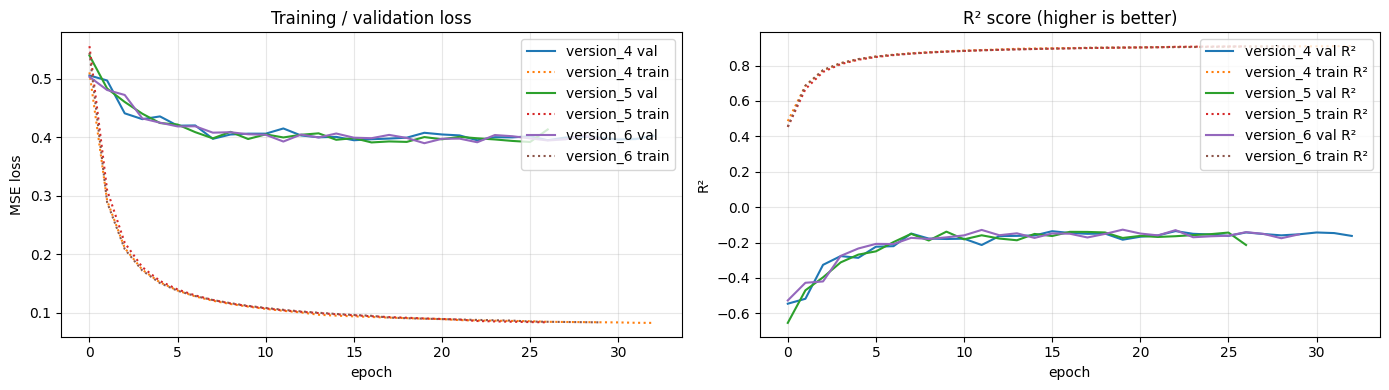

In [12]:
if not version_dirs:
    print('No logs available yet.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    for vdir in version_dirs[-3:]:
        csv = vdir / 'metrics.csv'
        if not csv.exists():
            continue
        m = pd.read_csv(csv)
        if 'val_loss' in m.columns:
            val_df = m.dropna(subset=['val_loss'])
            ax1.plot(val_df['epoch'], val_df['val_loss'], label=f"{vdir.name} val")
        if 'train_loss' in m.columns:
            tr_df = m.dropna(subset=['train_loss'])
            ax1.plot(tr_df['epoch'], tr_df['train_loss'], linestyle=':', label=f"{vdir.name} train")
        r2_col = next((c for c in m.columns if 'R2Score' in c and 'val' in c), None)
        r2_train_col = next((c for c in m.columns if 'R2Score' in c and 'train' in c), None)
        if r2_col:
            r2_df = m.dropna(subset=[r2_col])
            ax2.plot(r2_df['epoch'], r2_df[r2_col], label=f"{vdir.name} val R\u00b2")
        if r2_train_col:
            r2t_df = m.dropna(subset=[r2_train_col])
            ax2.plot(r2t_df['epoch'], r2t_df[r2_train_col], linestyle=':', label=f"{vdir.name} train R\u00b2")
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('MSE loss')
    ax1.set_title('Training / validation loss')
    ax1.grid(alpha=0.3)
    ax1.legend()
    ax2.set_xlabel('epoch')
    ax2.set_ylabel('R\u00b2')
    ax2.set_title('R\u00b2 score (higher is better)')
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()

### Optional: load best checkpoint for evaluation

If no checkpoint is available, we evaluate with the in-memory module.

In [13]:
best_ckpt = ckpt_callback.best_model_path if ckpt_callback.best_model_path else None
if best_ckpt and Path(best_ckpt).exists():
    module_eval = ClosureLitModule.load_from_checkpoint(best_ckpt, network=network)
    print('Loaded checkpoint:', best_ckpt)
else:
    module_eval = module
    print('No checkpoint found, using current module state.')

Loaded checkpoint: /volume1/scratch/georgem/closure/models/dev/dev16/checkpoints/epochepoch=019-vallossval_loss=0.3901.ckpt


In [14]:
datamodule.setup('test')

ground_truth, prediction = ev.transform_targets(
    module_eval,
    datamodule.test_dataset,
    target_channels=datamodule.target_channels,
    rescale=False,
    renorm=False,
    verbose=False,
    reshape=False,
    test_features=datamodule.test_dataset.features,
)

print('prediction shape :', prediction.shape)
print('ground_truth shape:', ground_truth.shape)

read_data: prior to appending outshape = (256, 256, 1)
Output shape (11, 10, 256, 256, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (11, 10, 256, 256)
read_data: prior to appending outshape = (256, 256, 1)
Output shape (11, 6, 256, 256, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (11, 6, 256, 256)


prediction shape : (720896, 6)
ground_truth shape: (720896, 6)


## 6) Evaluation metrics: MSE, MAE, RMSE, $R^2$, correlation

Use both the classic loss report and the new regression table for channel-wise diagnostics.

In [15]:
mse_report = ev.evaluate_loss(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    'MSELoss',
    target_channels=datamodule.target_channels,
    verbose=True,
)

r2_report = ev.evaluate_loss(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    'r2',
    target_channels=datamodule.target_channels,
    verbose=True,
)

metrics_df = ev.evaluate_regression_metrics(
    datamodule.test_dataset,
    ground_truth,
    prediction,
    target_channels=datamodule.target_channels,
)

display(metrics_df.sort_values('r2', ascending=False))

Total loss 0.8299097418785095
Loss for channel 0: Pxx_e, loss = 0.48913460969924927
Loss for channel 1: Pyy_e, loss = 0.5128266215324402
Loss for channel 2: Pzz_e, loss = 0.6695980429649353
Loss for channel 3: Pxy_e, loss = 1.1442716121673584
Loss for channel 4: Pxz_e, loss = 0.8580653667449951
Loss for channel 5: Pyz_e, loss = 1.305562138557434
Total loss -0.34074723720550537
Loss for channel 0: Pxx_e, loss = 0.20776623487472534
Loss for channel 1: Pyy_e, loss = 0.28131699562072754
Loss for channel 2: Pzz_e, loss = -0.09862232208251953
Loss for channel 3: Pxy_e, loss = -0.8658852577209473
Loss for channel 4: Pxz_e, loss = -0.9087942838668823
Loss for channel 5: Pyz_e, loss = -0.8927274942398071


,channel_index,channel,mse,rmse,mae,r2,pearson_r,mean_abs_ground_truth,nrmse
1,1,Pyy_e,0.512827,0.716119,0.551452,0.281317,0.813767,0.655672,1.092191
0,0,Pxx_e,0.489135,0.699382,0.568423,0.207766,0.829968,0.606004,1.154087
2,2,Pzz_e,0.669598,0.818290,0.651672,-0.098622,0.800848,0.609467,1.342632
3,3,Pxy_e,1.144272,1.069706,0.697603,-0.865885,0.055365,0.516674,2.070372
5,5,Pyz_e,1.305562,1.142612,0.800312,-0.892727,0.057454,0.588277,1.942303
4,4,Pxz_e,0.858065,0.926318,0.657144,-0.908795,0.011382,0.471578,1.964295


Plot a compact comparison of channel-wise $R^2$ and normalized RMSE.

Lower normalized RMSE and higher $R^2$ indicate better channel quality.

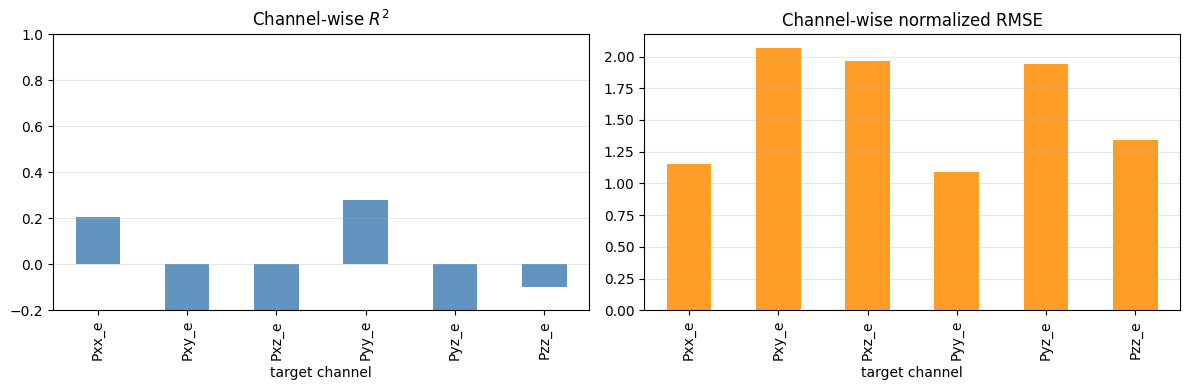

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_sorted = metrics_df.set_index('channel').sort_index()
metrics_sorted['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].grid(axis='y', alpha=0.3)

metrics_sorted['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')

plt.tight_layout()
plt.show()

## 7) Controlled visualization for diagonal vs off-diagonal components

The upgraded plotting helper supports robust scaling and signed-target handling.

invfunc = <ufunc 'exp'>


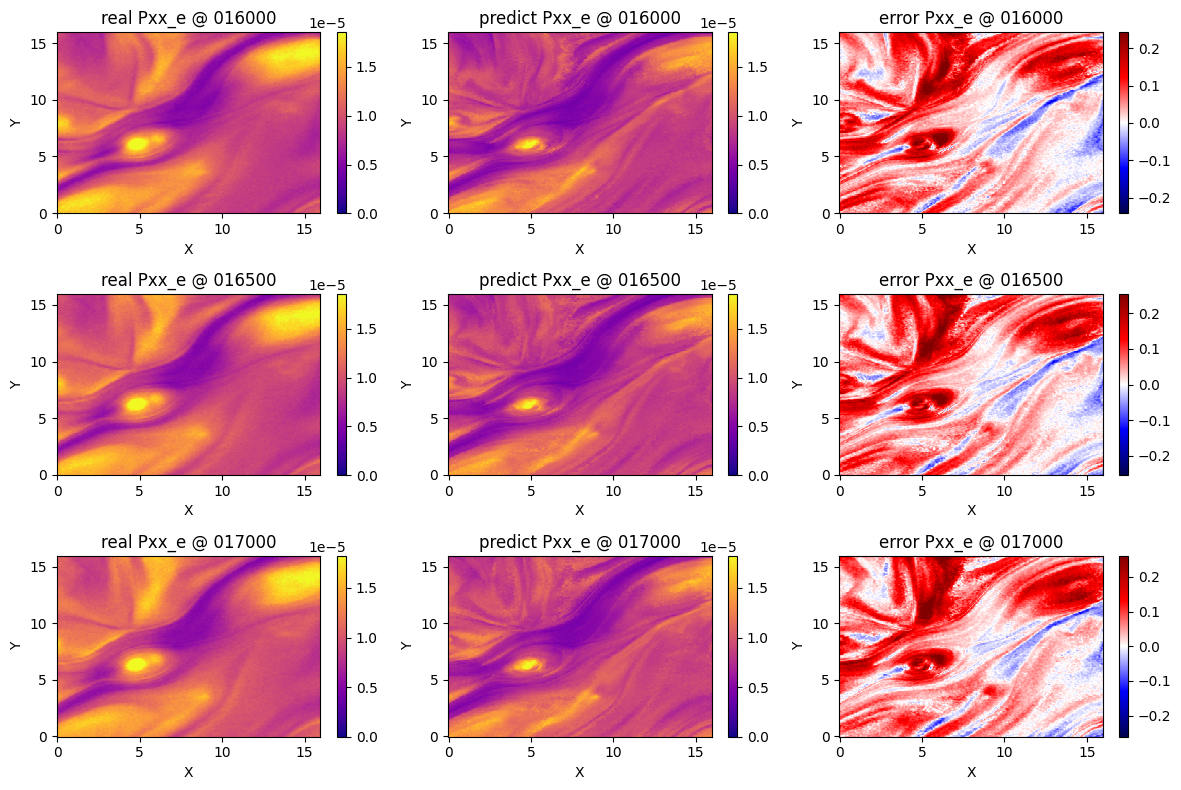

In [ ]:
plot_pred_targets(
    datamodule.test_dataset,
    'Pxx_e',
    prediction,
    ground_truth,
    data_folder=str(ecsim_dir),
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
    target_channels=datamodule.target_channels,
    output_dir=str(work_dir),
    plot_indices=[0, 1, 2],
    figsize=(12, 8),
    robust_quantile=0.995,
    error_mode='relative',
    signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'],
)

Off-diagonal channels are signed, so diverging maps are used with symmetric limits around zero.

invfunc = <function plot_pred_targets.<locals>.<lambda> at 0x7f5eb377fd80>


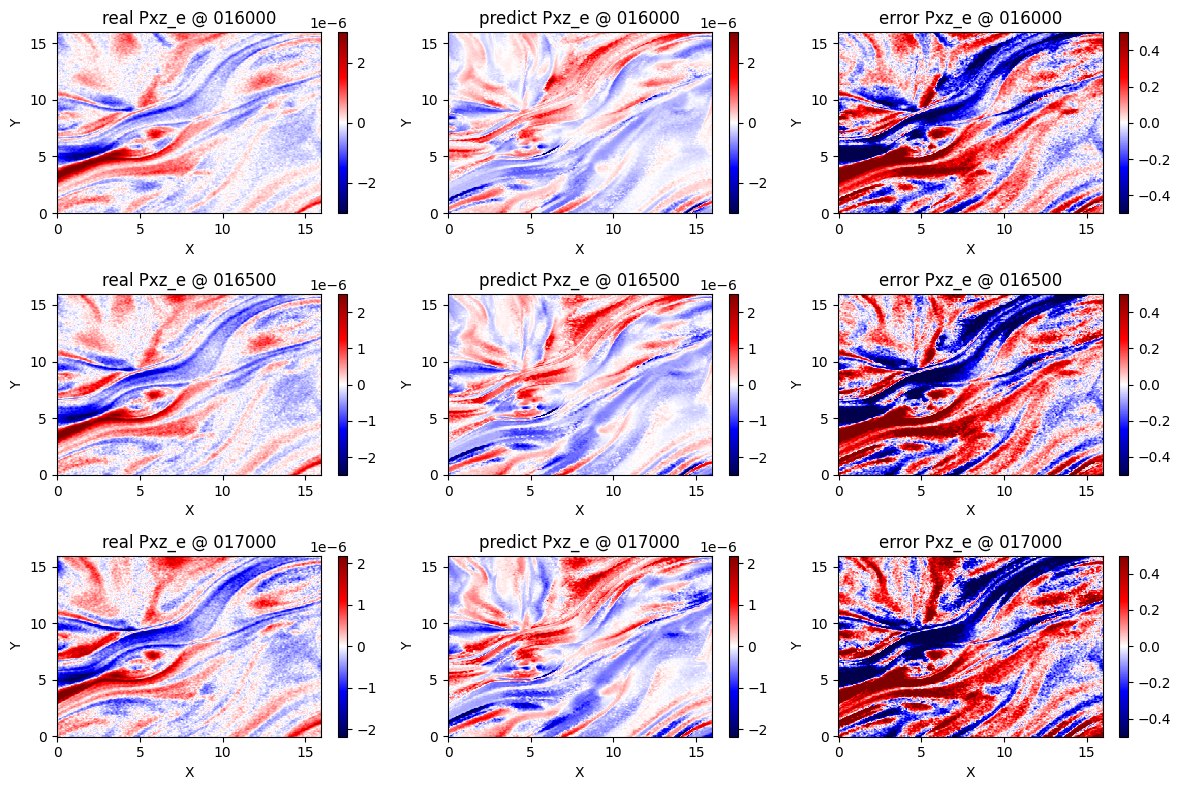

Plotted target: Pxz_e


In [ ]:
target_to_plot = 'Pxz_e' if 'Pxz_e' in datamodule.test_dataset.request_targets else datamodule.test_dataset.request_targets[0]
plot_pred_targets(
    datamodule.test_dataset,
    target_to_plot,
    prediction,
    ground_truth,
    data_folder=str(ecsim_dir),
    read_features_targets_kwargs=data_cfg['read_features_targets_kwargs'],
    target_channels=datamodule.target_channels,
    output_dir=str(work_dir),
    plot_indices=[0, 1, 2],
    figsize=(12, 8),
    robust_quantile=0.995,
    error_mode='symmetric_percent',
    error_limit=0.5,
    signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'],
)
print('Plotted target:', target_to_plot)

## 8) Compare multiple runs quickly from logger outputs

In [19]:
log_dirs = [str(p) for p in sorted((work_dir / 'lightning_logs').glob('version_*'))[-5:]]
run_summary = ev.compare_runs(log_dirs=log_dirs, metric_key='val_loss')
run_summary = run_summary.sort_values('best_val_loss', na_position='last')
display(run_summary)

,log_dir,best_val_loss,best_epoch
0,/volume1/scratch/georgem/closure/models/dev/de...,0.268192,8
1,/volume1/scratch/georgem/closure/models/dev/de...,0.280310,11
4,/volume1/scratch/georgem/closure/models/dev/de...,0.390099,19
3,/volume1/scratch/georgem/closure/models/dev/de...,0.391409,16
2,/volume1/scratch/georgem/closure/models/dev/de...,0.395062,22


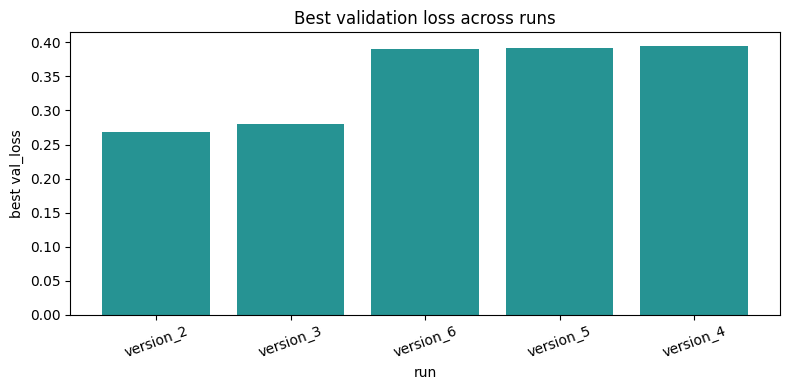

In [20]:
if run_summary.dropna(subset=['best_val_loss']).empty:
    print('No finite val_loss available yet.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_df = run_summary.dropna(subset=['best_val_loss']).copy()
    plot_df['run'] = [Path(x).name for x in plot_df['log_dir']]
    ax.bar(plot_df['run'], plot_df['best_val_loss'], color='teal', alpha=0.85)
    ax.set_ylabel('best val_loss')
    ax.set_xlabel('run')
    ax.set_title('Best validation loss across runs')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 9) Export a deployment bundle (.pt) that ships normalization with model weights

This bundle is convenient for downstream inference without separately tracking scaler files.

In [21]:
bundle_path = artifact_dir / 'inference_bundle.pt'

ds = datamodule.test_dataset
artifact_bundle = {
    'state_dict': module_eval.network.state_dict(),
    'model_kwargs': {
        'feature_dims': model_cfg['feature_dims'],
        'activations': model_cfg['activations'],
    },
    'request_features': ds.request_features,
    'request_targets': ds.request_targets,
    'target_channels': datamodule.target_channels,
    'feature_channels': datamodule.feature_channels,
    'features_mean': np.asarray(ds.features_mean),
    'features_std': np.asarray(ds.features_std),
    'targets_mean': np.asarray(ds.targets_mean),
    'targets_std': np.asarray(ds.targets_std),
    'prescaler_features': [None if f is None else f.__name__ for f in ds.prescaler_features],
    'prescaler_targets': [None if f is None else f.__name__ for f in ds.prescaler_targets],
    'flatten': ds.flatten,
}

torch.save(artifact_bundle, bundle_path)
print('Saved bundle:', bundle_path)

Saved bundle: /volume1/scratch/georgem/closure/models/dev/dev16/artifacts/inference_bundle.pt


Quick inspection of bundle metadata.

In [22]:
# PyTorch 2.6+ defaults to weights_only=True; handle both safe and full bundle formats.
try:
    loaded_bundle = torch.load(bundle_path, map_location='cpu', weights_only=True)
except Exception as e:
    print(f'weights_only load failed: {e}')
    print('Falling back to weights_only=False for trusted local artifact bundle...')
    loaded_bundle = torch.load(bundle_path, map_location='cpu', weights_only=False)

print('bundle keys:', sorted(list(loaded_bundle.keys())))
print('n_features:', len(loaded_bundle['request_features']))
print('n_targets :', len(loaded_bundle['request_targets']))
print('prescaler_targets:', loaded_bundle['prescaler_targets'])

weights_only load failed: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([_reconstruct])` or the `torch.serialization.safe_globals([_reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted b

## 10) Export TorchScript model (.pt) for integration in non-Python pipelines

Use `script` when the model is scriptable; fallback to `trace` if needed for custom modules.

In [23]:
torchscript_path = artifact_dir / 'torchscript.pt'

module_eval.network.eval()
example_input = torch.randn(32, model_cfg['feature_dims'][0])

try:
    scripted_model = torch.jit.script(module_eval.network.cpu())
except Exception as err:
    print('script failed, falling back to trace:', err)
    scripted_model = torch.jit.trace(module_eval.network.cpu(), example_input)

scripted_model.save(str(torchscript_path))
print('Saved TorchScript model:', torchscript_path)

Saved TorchScript model: /volume1/scratch/georgem/closure/models/dev/dev16/artifacts/torchscript.pt


## 11) Minimal inference utility using bundled normalization

In [24]:
def build_network_from_bundle(bundle):
    net = MLP(
        feature_dims=bundle['model_kwargs']['feature_dims'],
        activations=bundle['model_kwargs']['activations'],
    )
    net.load_state_dict(bundle['state_dict'])
    net.eval()
    return net


def predict_normalized(features_np, bundle, network=None):
    """Predict in normalized target space from raw feature rows.

    features_np shape: (n_samples, n_features)
    """
    if network is None:
        network = build_network_from_bundle(bundle)

    fmean = np.asarray(bundle['features_mean'])
    fstd = np.asarray(bundle['features_std'])
    x_norm = (features_np - fmean) / (fstd + 1e-12)

    with torch.no_grad():
        pred_norm = network(torch.tensor(x_norm, dtype=torch.float32)).cpu().numpy()
    return pred_norm

bundle_net = build_network_from_bundle(loaded_bundle)
sample_x = datamodule.test_dataset.features[:128].cpu().numpy()
sample_pred = predict_normalized(sample_x, loaded_bundle, network=bundle_net)
print('sample_pred shape:', sample_pred.shape)

sample_pred shape: (128, 6)


## 12) Save a run manifest for reproducibility

This captures the exact config, checkpoints, and exported artifacts for the run.

In [25]:
manifest = {
    'config_path': str(config_path),
    'train_csv': str(train_csv),
    'val_csv': str(val_csv),
    'test_csv': str(test_csv),
    'best_checkpoint': str(best_ckpt) if best_ckpt else None,
    'bundle_path': str(bundle_path),
    'torchscript_path': str(torchscript_path),
    'work_dir': str(work_dir),
}

manifest_path = artifact_dir / 'run_manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print('Saved manifest:', manifest_path)
print(json.dumps(manifest, indent=2))

Saved manifest: /volume1/scratch/georgem/closure/models/dev/dev16/artifacts/run_manifest.json
{
  "config_path": "/volume1/scratch/georgem/closure/models/dev/dev16/configs/model.yaml",
  "train_csv": "/volume1/scratch/georgem/closure/splits/split1/train.csv",
  "val_csv": "/volume1/scratch/georgem/closure/splits/split1/val.csv",
  "test_csv": "/volume1/scratch/georgem/closure/splits/split1/test.csv",
  "best_checkpoint": "/volume1/scratch/georgem/closure/models/dev/dev16/checkpoints/epochepoch=019-vallossval_loss=0.3901.ckpt",
  "bundle_path": "/volume1/scratch/georgem/closure/models/dev/dev16/artifacts/inference_bundle.pt",
  "torchscript_path": "/volume1/scratch/georgem/closure/models/dev/dev16/artifacts/torchscript.pt",
  "work_dir": "/volume1/scratch/georgem/closure/models/dev/dev16"
}


In [26]:
# Optional quick check: forward pass with TorchScript model
jit_model = torch.jit.load(str(torchscript_path), map_location='cpu')
with torch.no_grad():
    y_jit = jit_model(torch.tensor(sample_x[:16], dtype=torch.float32))
print('TorchScript output shape:', tuple(y_jit.shape))

TorchScript output shape: (16, 6)
